In [1]:
!pip install --upgrade gensim


[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import gensim
import gensim.downloader as api

In [12]:
dataset = api.load("text8")
model = gensim.models.Word2Vec(sentences=dataset,
                               vector_size=300,
                               window=3)

In [14]:
vec_king = model.wv['king']

In [16]:
words = ["king", "queen", "computer", "money", "city"]

for w in words:
    print(f"\nTop similar to '{w}':")
    print(model.wv.most_similar(w, topn=5))


Top similar to 'king':
[('prince', 0.6457152962684631), ('kings', 0.6323041915893555), ('emperor', 0.623092532157898), ('queen', 0.5898915529251099), ('pope', 0.5774266719818115)]

Top similar to 'queen':
[('elizabeth', 0.6787766814231873), ('princess', 0.6726446151733398), ('consort', 0.6637327671051025), ('prince', 0.639126181602478), ('victoria', 0.6387173533439636)]

Top similar to 'computer':
[('computers', 0.6709486246109009), ('console', 0.6107807755470276), ('computing', 0.5862631797790527), ('video', 0.5836718082427979), ('mainframe', 0.5686745643615723)]

Top similar to 'money':
[('profits', 0.6862713098526001), ('credit', 0.648317277431488), ('payment', 0.6360171437263489), ('cash', 0.6281481981277466), ('funds', 0.6207029819488525)]

Top similar to 'city':
[('town', 0.7211490273475647), ('cities', 0.6050214171409607), ('borough', 0.5754826664924622), ('downtown', 0.5653743743896484), ('metropolitan', 0.5129927396774292)]


In [17]:
analogies = [
    ("king", "man", "woman"),
    ("paris", "france", "italy"),
    ("walking", "walk", "run"),
]

for a, b, c in analogies:
    result = model.wv.most_similar(positive=[a, c], negative=[b], topn=1)
    print(f"{a} - {b} + {c} = {result}")

king - man + woman = [('queen', 0.5529099702835083)]
paris - france + italy = [('venice', 0.7038446068763733)]
walking - walk + run = [('running', 0.6417484879493713)]


In [21]:
from scipy.stats import spearmanr

pairs = [
    ("car", "automobile", 0.9),
    ("gem", "jewel", 0.85),
    ("journey", "voyage", 0.8),
    ("boy", "lad", 0.75),
    ("coast", "forest", 0.2),
    ("food", "rooster", 0.1),
]

model_scores = []
human_scores = []

for w1, w2, score in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        model_scores.append(sim)
        human_scores.append(score)

corr, _ = spearmanr(model_scores, human_scores)
print("Spearman correlation:", corr)

Spearman correlation: 0.48571428571428577


In [25]:
import numpy as np

def relation_vector(a, b):
    return model.wv[b] - model.wv[a]

v1 = relation_vector("man", "woman")
v2 = relation_vector("king", "queen")

cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2))
print("Gender direction similarity:", cos_sim)

Gender direction similarity: 0.17376728


In [26]:
print(model.wv.doesnt_match(["dog", "cat", "banana", "horse"]))

banana


In [27]:
def neighbor_purity(word, category_words):
    neighbors = [w for w, _ in model.wv.most_similar(word, topn=10)]
    overlap = len(set(neighbors) & set(category_words))
    return overlap / 10

print("Dog purity:", neighbor_purity("dog", animals))

Dog purity: 0.1


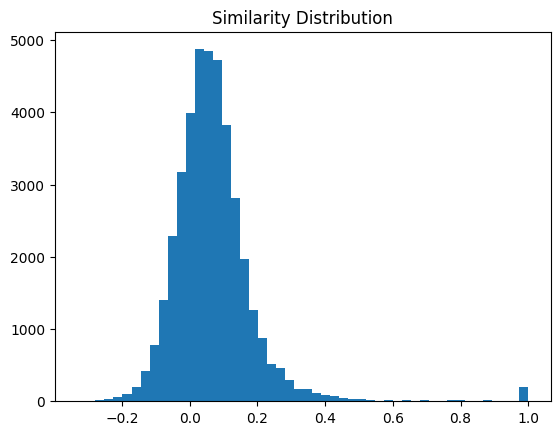

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

vecs = model.wv[model.wv.index_to_key[:200]]
sim_matrix = cosine_similarity(vecs)

plt.hist(sim_matrix.flatten(), bins=50)
plt.title("Similarity Distribution")
plt.show()